## The CHSH Game

This is a type of "nonlocal" game. Nonlocal basically means faster-than-light communication, in physics, hence we can guess that the property of entanglement is used to achieve best results.  

The setup involves two players, commonly named as Alice and Bob, and a refree, say Charlie. Alice and Bob are very, very far away from each other (say in two different galaxies) hence we can comfortably say that they cannot communicate with each other.   

Charlie chooses two questions, x for Alice, and y for Bob, according to some probability distribution p(x,y). Upon recieving the respective questions,  
Alice: returns answer 'a'  
Bob: returns answer 'b'  

In the CHSH game, Alice and Bob win iff   
x.y = a⊕b  
here, x.y = 1 iff both x and y are 1  
a⊕b = 1 iff both x and y are different.  

(The classical strategy involves Alice and Bob pre-deciding to give the same output, i.e, either 1 or 0, for every x and y, which yields 75% success rate.)  

Quantum strategy  
This involves the use of entanglement (Alice and Bob share an entangled state).  

Let   
|Ψ(θ)> = cosθ|0> + sinθ|1> be a qubit state unit vector  
U(θ) = |0><Ψ(θ)| + |1><Ψ(θ+ π/2)| be a unitary matrix  

Alice has a qubit A, Bob has B and together they share an e-bit in the |Φ+> Bell state. Alice and Bob apply U(θ) according to the input as shown in the diagrams below.  

This strategy selectively maximizes the probability of the favorable outcome (a,b) according to the given question (x,y). We can think as if the quantum strategy is 'personalizing' the game.   
For example, when x.y = 0, the probability of a==b will be maximized, and when x.y = 1, the probability of a!=b will be maximized. The detailed analysis is provided below.


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from math import pi
from IPython.display import display
import random
def circuit (x, y):
    chsh = QuantumCircuit(2,2)

    # Create the entangled bit in the Bell state
    chsh.h(0)
    chsh.cx(0,1)

    # Alice's measurement basis
    # x = 0 --> no rotation
    # x = 1 --> rotate by -pi/2 around y-axis

    if x == 0:
        chsh.ry(0, 0)
    else:
        chsh.ry(-pi/2, 0)

    # Bob's measurement basis
    
    if y == 0:
        chsh.ry(-pi/4, 1)
    else:
        chsh.ry(pi/4, 1)
    
    chsh.measure(0,0)
    chsh.measure(1,1)
    return chsh

(x,y) = (1,1)


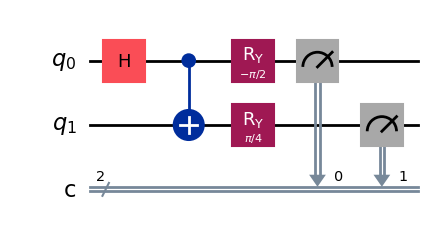

In [3]:
# Visualizing with an example where x and y are randonly selected.
x, y = random.randint(0, 1), random.randint(0, 1)
print("(x,y) = ("+ str(x) + "," + str(y) + ")")
display(circuit(x,y).draw(output="mpl"))

In [4]:
def win_or_lose(strategy):
    a, b = strategy(x, y)
    if (a != b) == (x & y):
        return 1
    return 0 

In [5]:
from qiskit_aer import AerSimulator
def quantum_strategy(x, y):
    
    result = AerSimulator().run(circuit(x, y), shots=1).result()
    statistics = result.get_counts()
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

In [6]:
score = 0
for _ in range(101):
    score += win_or_lose(quantum_strategy)
print("Winning rate is", 100*score/101)

Winning rate is 89.10891089108911
